# House Price Prediction using Regression Models

## Objective

The objective of this project is to predict housing prices using multiple regression models and compare their performance using MAE, MSE, and R² Score.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

print("Dataset loaded successfully.")


df.to_csv(
    "../data/housing.csv",
    index=False
)

print("Dataset saved successfully.")


Dataset loaded successfully.
Dataset saved successfully.


## 2. Dataset Preview

In [4]:
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 4. Dataset Dimensions

In [6]:
rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Rows    : 20640
Columns : 9


## 5. Missing Value Analysis

Missing values were checked before model development to ensure data quality.

In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

### Observation

No missing values were found in the dataset. Therefore, no missing value treatment was required.

## 6. Feature and Target Selection

The input features were separated from the target variable (HousePrice).

In [8]:
X = df.drop(columns=["HousePrice"])

y = df["HousePrice"]

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


## 7. Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (16512, 8)
Testing Shape  : (4128, 8)


## 8. Feature Scaling

Standardization was applied to numerical features before training the regression models.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


## 9. Linear Regression

A Linear Regression model was trained to establish a baseline for comparison.

In [11]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Linear Regression Performance

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("R2  :", linear_r2)

MAE : 0.5332001304956565
MSE : 0.5558915986952444
R2  : 0.5757877060324508


## 10. Polynomial Regression

Polynomial features were generated to capture non-linear relationships between housing attributes and house prices.

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train_scaled
)

X_test_poly = poly.transform(
    X_test_scaled
)

print(X_train_poly.shape)
print(X_test_poly.shape)

(16512, 44)
(4128, 44)


In [14]:
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

poly_predictions = poly_model.predict(
    X_test_poly
)

print("Polynomial Regression trained successfully.")

Polynomial Regression trained successfully.


In [15]:
poly_mae = mean_absolute_error(
    y_test,
    poly_predictions
)

poly_mse = mean_squared_error(
    y_test,
    poly_predictions
)

poly_r2 = r2_score(
    y_test,
    poly_predictions
)

print("MAE :", poly_mae)
print("MSE :", poly_mse)
print("R2  :", poly_r2)

MAE : 0.46700093346965726
MSE : 0.4643015238301175
R2  : 0.645681972926194


### Observation

Polynomial Regression outperformed Linear Regression across all evaluation metrics. The increase in R² score indicates that polynomial features helped capture non-linear relationships present in the housing data.

## 11. Ridge Regression

Ridge Regression applies L2 regularization to reduce overfitting and improve model stability.

In [16]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [17]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("R2  :", ridge_r2)

MAE : 0.5331931195789734
MSE : 0.555854858943597
R2  : 0.5758157428913684


### Observation

Ridge Regression produced results very similar to Linear Regression. The model maintained stable performance but did not significantly improve prediction accuracy, suggesting that regularization was not a major requirement for this dataset.

## 12. Lasso Regression

Lasso Regression applies L1 regularization and can reduce the impact of less important features.

In [18]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.001)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_predictions = lasso_model.predict(
    X_test_scaled
)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [19]:
lasso_mae = mean_absolute_error(
    y_test,
    lasso_predictions
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_predictions
)

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)

print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("R2  :", lasso_r2)

MAE : 0.5331447750392391
MSE : 0.5544913600832686
R2  : 0.5768562568705682


## 13. Model Comparison

The performance of all regression models was compared using MAE, MSE, and R² Score.

In [20]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae
    ],
    "MSE": [
        linear_mse,
        poly_mse,
        ridge_mse,
        lasso_mse
    ],
    "R2 Score": [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison_df

,Model,MAE,MSE,R2 Score
0,Linear Regression,0.533200,0.555892,0.575788
1,Polynomial Regression,0.467001,0.464302,0.645682
2,Ridge Regression,0.533193,0.555855,0.575816
3,Lasso Regression,0.533145,0.554491,0.576856


### Observation

Polynomial Regression achieved the best overall performance with the lowest MAE and MSE values and the highest R² Score. This indicates that the relationship between housing features and house prices contains non-linear patterns that were captured effectively by polynomial features.

Linear, Ridge, and Lasso Regression produced similar results, suggesting that regularization had limited impact on this dataset.

## 14. Best Model Selection

Among all evaluated models, Polynomial Regression achieved the highest R² Score and the lowest MAE and MSE values.

Therefore, Polynomial Regression was selected as the best-performing model for this house price prediction task.

## 14. Actual vs Predicted Values

This visualization compares actual house prices with predictions generated by the best-performing model.

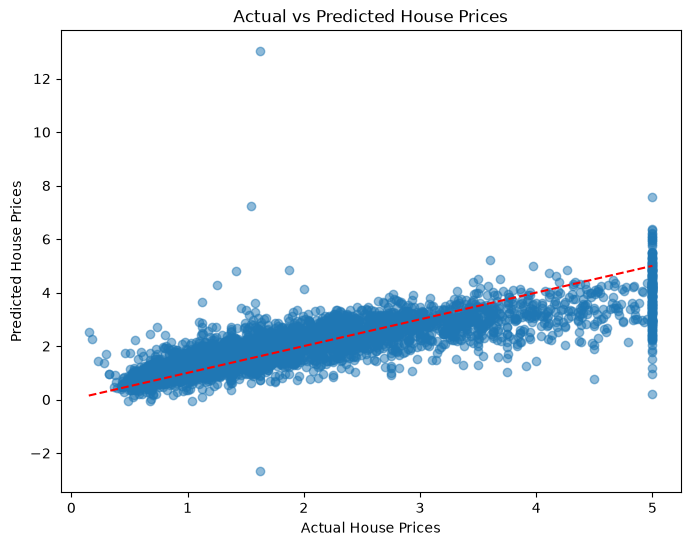

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    poly_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()



### Observation

Most points lie near the ideal prediction line, indicating that the Polynomial Regression model generates predictions close to actual house prices. While a few outliers exist, the overall trend demonstrates a strong positive relationship between actual and predicted values.

This confirms that Polynomial Regression effectively captures non-linear patterns in the housing data and provides the best performance among the evaluated models.